# analysis.detection-statistics


## Summary 

In this notebook, we focus on the numbers generated by our bacteria-taxonomic profiling using MOTUs.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import taxoniq
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

## Bacteria


### How many bacteria were detected?

To know that, first we need to load the data. 

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_bacteriaHits').df().query('scientific_name != ""').copy()
site_data = db.conn.sql('SELECT * FROM D_sites').df()

In [3]:
len(bacteria_hits['library'].unique())

297

In [4]:
bacteria_hits.value_counts(['scientific_name', 'library']).reset_index()

,scientific_name,library,count
0,Achromobacter xylosoxidans,PV154,1
1,Pseudomonas sp. Leaf127,PV215,1
2,Pseudomonas sp. Leaf127,PV188,1
3,Pseudomonas sp. Leaf127,PV174,1
4,Pseudomonas sp. Leaf127,PV117,1
...,...,...,...
1466,Herbiconiux solani,PV215,1
1467,Herbiconiux solani,PV078,1
1468,Herbiconiux solani,PV025,1
1469,Herbiconiux ginsengi,PV078,1


The data contains hits. We need to aggregate the hits to get the OTUs to which they map, which we do by a simple `value_counts`. 

In [5]:
bacteria_hits_count = bacteria_hits.value_counts(['scientific_name']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits)
bacteria_hits_count

,scientific_name,count,rank,%
0,uncultured Clostridium sp.,252,1,0.171312
1,Frigoribacterium sp. Leaf164,26,2,0.017675
2,Cutibacterium acnes,21,3,0.014276
3,Pseudomonas lutea,21,4,0.014276
4,Rhodococcoides fascians,21,5,0.014276
...,...,...,...,...
515,Auraticoccus monumenti,1,516,0.000680
516,Microbacterium ginsengisoli,1,517,0.000680
517,Microbacterium azadirachtae,1,518,0.000680
518,Methylopila sp. 73B,1,519,0.000680


In [6]:
bacteria_hits_count.query('scientific_name == ""')

,scientific_name,count,rank,%


In [7]:
number_hits = len(bacteria_hits.value_counts(['scientific_name', 'library']).reset_index())
number_otus = len(bacteria_hits_count)

db.add_value("motus_number_hits", "Number of bacteria detections by MOTUS", value=number_hits, type='INTEGER')
db.add_value("motus_number_OTUs", "Number of different bacteria OTU detected by MOTUS", value=number_otus, type='INTEGER')

print("Total hits {:6d}".format(len(bacteria_hits))) # 1472
print(" |--> corresponding to {:6d} bacterial OTUs".format(number_otus)) # 520


Total hits   1471
 |--> corresponding to    520 bacterial OTUs


We have 1486 hits corresponding to 519 OTUs. Now, let's see how they distribute. 

In [8]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))}, # 311
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 211
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, # 113 
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 43
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 22
    ]
)



,threshold,count
0,=1,309
1,>1,211
2,>2,113
3,>5,42
4,>10,22


Most OTUs (> 300) have been detected only one. A ranking map of these OTUs should help us see this pattern. In the folllowing plot, we are sorting by growing rank the OTUs depending on their number of hits. On the left, we would find the OTUs with higher number of hits, on the right those with the lower number of hits. 

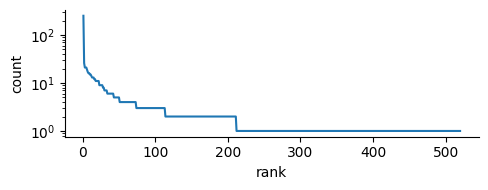

In [9]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.5
)
# g.ax.axvline(10, linestyle='--', color='gray')
g.ax.set_yscale('log')


We can observe indeed a very heterogeneous distribution, with some hits exceeding the 100 detections. Let's see which could be these organisms.

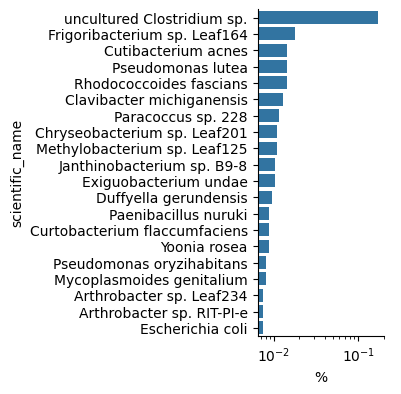

In [10]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar', height=4.0, aspect=1.0
)
g.ax.set_xscale('log')

This is quite interesting:
- The most abundant organism is an *uncultured Clostridium sp.*. This means that it could be whatever.
- After that one, we have some organism that are indeed known for interacting with plants such as *Pseudomonas lutea*.
- We also find unexpected items, such as *Escherichia coli* and *Mycoplasmoides genitalium*. This could mean that our samples are either contaminated by animal associated bacteria.

## Plant associated bacteria

We are considering as PABs all those bacteria's that are described in Sanchis et al. 2021 - supplementary material, table 1.


In [11]:
bacteria_hits_count = bacteria_hits.query('is_pab == True').value_counts(['scientific_name', 'taxid', 'pab_type']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits.query('is_pab == True'))
bacteria_hits_count

,scientific_name,taxid,pab_type,count,rank,%
0,Frigoribacterium sp. Leaf164,1736282,pab_unknown,26,1,0.060046
1,Rhodococcoides fascians,1828,pab_unknown,21,2,0.048499
2,Pseudomonas lutea,243924,pab_unknown,21,3,0.048499
3,Methylobacterium sp. Leaf125,1736265,pab_unknown,16,4,0.036952
4,Chryseobacterium sp. Leaf201,1735672,pab_unknown,16,5,0.036952
...,...,...,...,...,...,...
122,Pseudomonas sp. Leaf48,1736221,pab_unknown,1,123,0.002309
123,Cupriavidus basilensis,68895,pab_unknown,1,124,0.002309
124,Pseudomonas vancouverensis,95300,pab_unknown,1,125,0.002309
125,Pseudorhodoferax sp. Leaf265,1736315,pab_unknown,1,126,0.002309


In [12]:


number_hits = len(bacteria_hits.query('is_pab == True').value_counts(['scientific_name', 'library']).reset_index())
number_otus = len(bacteria_hits_count)

db.add_value("motus_number_hits", "Number of PAB detections by MOTUS", value=number_hits, type='integer')
db.add_value("motus_number_OTUs", "Number of different PAB OTU detected by MOTUS", value=number_otus, type='integer')



print("Total PAB hits {:6d}".format(number_hits)) # 433 q000011
print(" |--> corresponding to {:6d} PAB OTUs".format(number_otus)) # 127 q000012


Total PAB hits    433
 |--> corresponding to    127 PAB OTUs


We have a total of 433 PAB hits, corresponding to 127 OTUs. These numbers might have been slightly higher in the past, given some errors when counting organisms. Let's take again one look at the count.

In [13]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))},# 53 
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 74
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, #45
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 20
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 9
    ]
)

,threshold,count
0,=1,53
1,>1,74
2,>2,46
3,>5,20
4,>10,9


The numbers are quite brutal again. Two fifths of the data have only one positive hit. Let's look at this again with a rank-plot. 

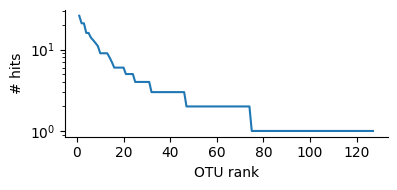

In [14]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("OTU rank")
g.set_ylabels("# hits")

g.savefig("figures/rankplot.pab-bacteria.png", dpi=300)

Now we can take a quick look at the composition of these bacteria.

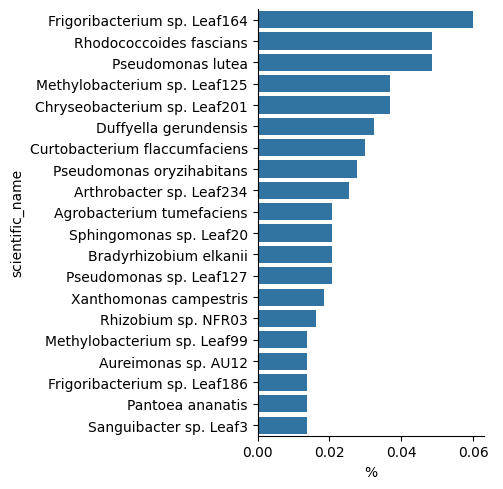

In [15]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar'
)
# g.ax.set_xscale('log')

### What is the high-level taxonomic composition of our PABs?

While we have the species represented in the plot above, higher-taxonomy levels might provide another picture. We will use Taxoniq to compute the taxon, class, order, etc of each of the taxa, and we will dump it in a figure. 

In [16]:
bacteria_hits_count

,scientific_name,taxid,pab_type,count,rank,%
0,Frigoribacterium sp. Leaf164,1736282,pab_unknown,26,1,0.060046
1,Rhodococcoides fascians,1828,pab_unknown,21,2,0.048499
2,Pseudomonas lutea,243924,pab_unknown,21,3,0.048499
3,Methylobacterium sp. Leaf125,1736265,pab_unknown,16,4,0.036952
4,Chryseobacterium sp. Leaf201,1735672,pab_unknown,16,5,0.036952
...,...,...,...,...,...,...
122,Pseudomonas sp. Leaf48,1736221,pab_unknown,1,123,0.002309
123,Cupriavidus basilensis,68895,pab_unknown,1,124,0.002309
124,Pseudomonas vancouverensis,95300,pab_unknown,1,125,0.002309
125,Pseudorhodoferax sp. Leaf265,1736315,pab_unknown,1,126,0.002309


In [17]:
bacteria_hits_count['taxon'] = bacteria_hits_count['taxid'].apply(lambda x: taxoniq.Taxon(x))
bacteria_hits_count['class'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'class'][0])
bacteria_hits_count['order'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'order'][0])
bacteria_hits_count['phylum'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'phylum'][0])

In [18]:
len(bacteria_hits_count.order.unique())

18

In [19]:
bacteria_hits_count.phylum.unique()

array(['Actinomycetota', 'Pseudomonadota', 'Bacteroidota', 'Bacillota'],
      dtype=object)

The following figure should represent the phylum (color) and the order (row) of all the species detected. 

In [20]:
bacteria_taxonomies = bacteria_hits_count.value_counts(['order', 'phylum']).reset_index()
top10 = bacteria_taxonomies.groupby(['order'])['count'].sum().reset_index().sort_values(by='count', ascending=False)[:10].order.values
bacteria_taxonomies['order'] = bacteria_taxonomies['order'].apply(lambda x: x if x in top10 else 'Other')
bacteria_taxonomies['phylum'] = bacteria_taxonomies.apply(lambda x: x.phylum if x.order != 'Other' else 'Other', axis=1)

In [21]:
bacteria_taxonomies = bacteria_taxonomies.groupby(['order', 'phylum'], as_index=False)['count'].sum().sort_values(by='count', ascending=False)
bacteria_taxonomies

,order,phylum,count
3,Hyphomicrobiales,Pseudomonadota,30
4,Micrococcales,Actinomycetota,24
0,Burkholderiales,Pseudomonadota,18
8,Pseudomonadales,Pseudomonadota,17
6,Other,Other,10
1,Enterobacterales,Pseudomonadota,8
10,Sphingomonadales,Pseudomonadota,8
9,Sphingobacteriales,Bacteroidota,4
2,Flavobacteriales,Bacteroidota,3
7,Propionibacteriales,Actinomycetota,3


Saved P_PABtaxonomy to db.2026-02-24


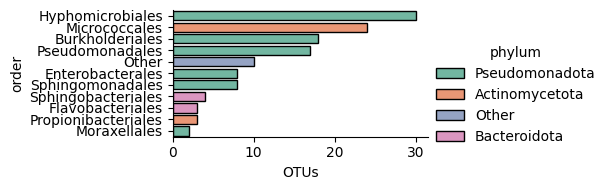

In [22]:
db.save_dataframe(
    bacteria_taxonomies, table_name="P_PABtaxonomy",
    description="Number of PAB hits belonging to each different phylum and order"
)
g = sns.catplot(
    bacteria_taxonomies, x='count', hue='phylum', y='order', kind='bar', edgecolor='black', height=2., aspect=2.5, dodge=False,
    palette='Set2'
)
g.set_xlabels("OTUs")
g.savefig("figures/catplot.detections-taxonomic-composition.colbyphyla.svg")

### What kind of PABs?

Sanchis et al. (2021) consider three types of PABs:
- *symbionts*, which we prefer to call *mutualists*
- *pathogens*, which we should call *antagonists* —but we won't.
- *unknown*, those that have an uncertain relationship with the hosts.

We are going to generate a table the considers the numbers of each of these PAB types among our OTUs.

In [23]:
pab_types = bacteria_hits_count.value_counts(['pab_type']).reset_index().rename(columns={'count': 'OTUs'})
db.save_dataframe(
    pab_types, table_name="D_PABTypeCounts",
    description="Occurrences of the different kinds of PABs"
)


db.add_value(name="number_PAB_unknown_OTU", description="how many PAB OTUs had unknown function", value=int(pab_types.set_index('pab_type').loc['pab_unknown', 'OTUs']), type="INTEGER")
db.add_value(name="number_PAB_symbiont_OTU", description="how many PAB OTUs had symbiont function", value=int(pab_types.set_index('pab_type').loc['pab_symbiont', 'OTUs']), type="INTEGER")
db.add_value(name="number_PAB_pathogen_OTU", description="how many PAB OTUs had pathogen function", value=int(pab_types.set_index('pab_type').loc['pab_pathogen', 'OTUs']), type="INTEGER")
pab_types

Saved D_PABTypeCounts to db.2026-02-24


,pab_type,OTUs
0,pab_unknown,96
1,pab_symbiont,17
2,pab_pathogen,14


## Libraries

Again, simple Q & A

### What is the distribution of hits across our libraries?

To answer this question, first we need to value-count the number of total hits per library. We all save the habitat. 

In [24]:
bacteria_hits = pd.merge(bacteria_hits, site_data, on='library', how='left')
bacteria_hits

,library,taxid,scientific_name,is_pab,pab_type,site,habitat,n_extracts,host_taxon
0,PV001,2097,Mycoplasmoides genitalium,False,,M1,Crop,8.0,Amaranthus sp
1,PV002,59620,uncultured Clostridium sp.,False,,M1,Crop,11.0,Convolvulus arvensis
2,PV002,2097,Mycoplasmoides genitalium,False,,M1,Crop,11.0,Convolvulus arvensis
3,PV002,69896,Candidatus Phytoplasma solani,False,,M1,Crop,11.0,Convolvulus arvensis
4,PV003,641148,Neisseria sp. oral taxon 014,False,,M1,Crop,13.0,Cucumis melo
...,...,...,...,...,...,...,...,...,...
1475,PV587,317,Pseudomonas syringae,True,pab_pathogen,H1,Crop,8.0,Hirschfeldia incana
1476,PV587,1886670,Paenibacillus nuruki,False,,H1,Crop,8.0,Hirschfeldia incana
1477,PV588,59620,uncultured Clostridium sp.,False,,H1,Crop,8.0,Hordeum vulgare
1478,PV588,43675,Rothia mucilaginosa,False,,H1,Crop,8.0,Hordeum vulgare


In [25]:
library_hits_count = bacteria_hits.value_counts(['library', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,habitat,count,rank
0,PV215,Edge,138,0
1,PV527,Crop,104,1
2,PV078,Wasteland,71,2
3,PV212,Edge,51,3
4,PV218,Edge,43,4
...,...,...,...,...
291,PV136,Edge,1,291
292,PV135,Edge,1,292
293,PV134,Edge,1,293
294,PV133,Edge,1,294


The following table indicates some values of the distribution.

In [26]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count > 0'))}, #323
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))}, #107
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))}, #211
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,296
1,=1,85
2,>1,211
3,>2,134
4,>5,58
5,>10,22


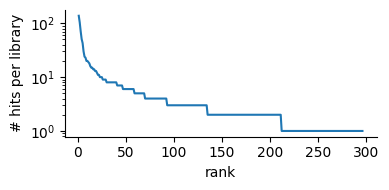

In [27]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot",
#     description="Ranking of sites depending on their detections"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("rank")
g.set_ylabels("# hits per library")

### How many PAB detections per library?

As simple as the analysis above, but just analyzing PAB hits.

In [28]:
library_hits_count = bacteria_hits.query('is_pab == True').value_counts(['library', 'site', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,site,habitat,count,rank
0,PV215,L3,Edge,43,0
1,PV078,E4,Wasteland,37,1
2,PV527,Z2,Crop,28,2
3,PV212,L3,Edge,14,3
4,PV525,Z1,Crop,10,4
...,...,...,...,...,...
130,PV089,Q1,Oak,1,130
131,PV084,Q1,Oak,1,131
132,PV083,Q1,Oak,1,132
133,PV075,E2,Wasteland,1,133


In [29]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))},
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))},
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,61
1,>1,74
2,>2,50
3,>5,14
4,>10,4


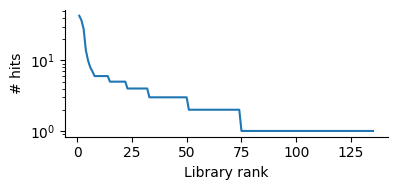

In [30]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot_PAB",
#     description="Ranking of sites depending on their detections of PAB OTUs"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("Library rank")
g.set_ylabels("# hits")
g.savefig("figures/rankplot.pab-library.png", dpi=300)

In [31]:
db.conn.close()